# DEF-D Fysieke Ontwerpopdracht 5 Invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 33     |  |
| :-------------|:-------------|
| Mehraj Khalid| 6590276 |
| Celeste de Jong| 6290728 |
| Félicie van der Leij| 6210392 |

## Opdracht 1: Planning.

| Planning Groep: 33     |Tijdstip / Tijdspanne  | door wie  |
|---|---|---|
| Arduino testen| 11:00 - 12:00 | Celeste |
| ontwerp-eis berekenen| 11:00 - 12:00 | Mehraj, Félicie|
| bouwen van 1e opstelling en test meting | 13:45 - 15:30 | hele groep |
| itereren en opstelling verbeteren | 15:45 - 17:00 | hele groep |
| accelometer en arduino werkend | 12:45 | ---|
| trillingsvrije opstelling af | 17:30 | ---|
| Pauze 1| 12:45 - 13:45 | hele groep |
| Pauze 2| 15:30 - 15:45 | hele groep |

Run onderstaande cel om alle benodigde libraries te laden. Mogelijk voeg je er zelf nog een aantal toe later vandaag. 

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
import math

## Opdracht 2a: Opsplitsen taak 1: Arduino
Vul onderstaande tabel in:


| onderwerp    | antwoord  |
|---|---|
| hoe moeilijk (schaal 1 - 10) |5  |
| hoe lang voor één meting | 10 seconden |
| verwacht nauwkeurigheid meting | 0,1 Hz |

## Opdracht 2b: Opsplitsen taak 2: afleiding ontwerpeis

In [2]:
# Bereken hier je benodigde kantelfrequentie
kantelfrequentie = 2.5

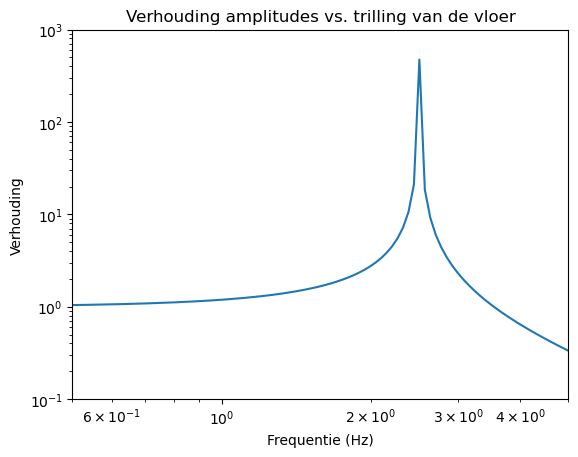

In [3]:
#verhouding = np.linspace(0, 100,101)

f = np.logspace(-1, 10, 1000)

def verhouding(f):
    return np.abs(1 / (1-((f)**2/(kantelfrequentie)**2)))

y = verhouding(f)

# Voeg hier je plot in.
plt.figure()
plt.loglog(f, y)
plt.xlim(left=0.5,right = 5)
plt.ylim(bottom=0.1, top=1e3)
plt.xlabel('Frequentie (Hz)')
plt.ylabel('Verhouding')
plt.title('Verhouding amplitudes vs. trilling van de vloer')
plt.show()



In [4]:
# Bereken hier de minimale Delta-x waarbij je aan de eis van de opdracht voldoet.
g = 9.81
d_x = g / (2 * math.pi * kantelfrequentie)**2
print(d_x)



0.039758432461253344


## Opdracht 3: Plot de grafiek.

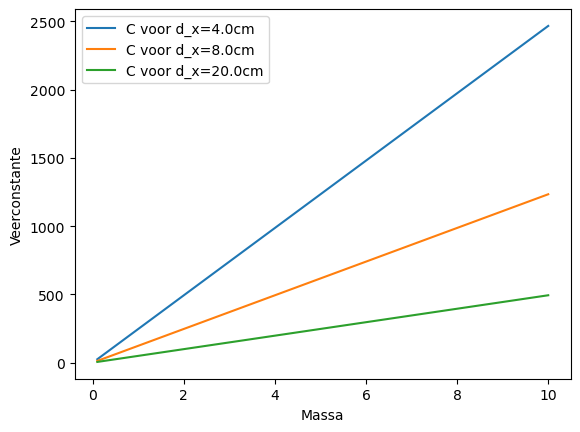

In [5]:
# Voeg hier je plot in. Lees goed de opdracht wat er in de grafiek moet staan!
# Het is ook handig om je grafiek op te slaan, doe dat door met plt.savefig().
m = np.linspace(0.1, 10, 100)
def c (m,d_x):
    return (m * g)/ d_x
c_0 = c(m,d_x) 
c_2 = c(m,2*d_x)
c_5 = c(m,5*d_x)
plt.figure()
plt.plot(m, c_0, label="C voor d_x=4.0cm")
plt.plot(m, c_2, label="C voor d_x=8.0cm")
plt.plot(m, c_5, label="C voor d_x=20.0cm")
plt.xlabel('Massa')
plt.ylabel('Veerconstante')
plt.legend()

## Opdracht 4: Verander $\Delta x$.

We kunnen $\Delta x$ verhogen door:

- Door de massa op de veer te
 verhogen.
- Door een minder stuggere veer te nemen, dus de veerconstante wordt kleiner.

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

Als groep gaan we mikken op een $\Delta x$ van: 8 cm, zodat we kunnen varieren tussen lage veerconstantes.


Voor de schatting van het oppervlakte. We hebben besloten om de Diameter van het oppervlakte te schatten. We hebben als bovengrens 5 cm gekozen (50mm), en als ondergrens 1 mm.
Dus dan hebben we D = sqrt(1 * 50) = sqrt(10) * sqrt(5) = 2.3 * 3 = 7 mm. Dus is A = 0.8 * 7^2 = 40 vierkante millimeters. (Alleen "=" zijn een "ongeveer gelijk aan")

In [6]:
c_veer = c(6, 2*d_x)
print(c_veer)
L = 0.75 #m
A = 40e-6 #m^2

E = c_veer * L / A
print(E)


740.2203300817018
13879131.189031908


We gaan mikken op een delta_x van 8 mm zdoat we ver genoeg zitten van de minimale 4 cm nodig om aan de eisen van de opdracht te voldoen, maar die ook niet te groot is dat het niet uitvoerbaar is met de materialen die wij kunnen gebruiken.

## Opdracht 5: Schets.

##### schets opstelling: 
<img src="schets8.jpg" width="400">

## Opdracht 6: Beslissing evaluatie

Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?

**8 cm**

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

**Ja**

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

**15 cm**

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

**ja, er is genoeg verschil tussen de limiet en gemikte $\Delta x$ om metingen te doen**

### Gaat je ontwerp dus voldoen aan de eis?

**Ja**

Als je hier positief geantwoord heb, maak dan nog een keer een plot van amplitude overdracht (y-as) versus frequentie (x-as) zoals je hierboven ook al een keer gedaan heb, maar plot nu twee verschillende overdrachten in de grafiek: één die je al had: behorende bij de grens van de ontwerp-eis en één behorende bij je eigen ontwerp. Lees af dat je voor je ontwerp daadwerkelijk onder de eis grafiek zit op de kritieke frequentie!

Deze grafiek heb je later weer nodig om je gemeten punten aan toe te voegen. Ga daarna je massa-veer systeem daadwerkelijk bouwen.

Als je hier negatief geantwoord hebt, kopieer onder deze cel dan alle cellen van Synthese tot en met Evaluation & decision en doorloop dat deel van het ontwerp proces nogmaals.

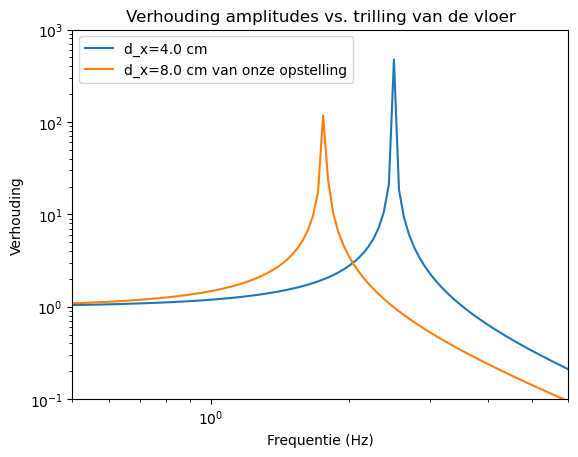

In [7]:
# Voeg hier je plot in.
#verhouding = np.linspace(0, 100,101)
# Bereken hier je benodigde kantelfrequentie
kantelfrequentie = 2.5
f = np.logspace(-1, 10, 1000)

def verhouding(f):
    return np.abs(1 / (1-((f)**2/(kantelfrequentie)**2)))

y = verhouding(f)

kantelfrequentie2= np.sqrt(9.81/0.08)/(2*np.pi)

def verhouding2(f):
    return np.abs(1 / (1-((f)**2/(kantelfrequentie2)**2)))

y2= verhouding2(f)

    
 
# Voeg hier je plot in.
plt.figure()
plt.loglog(f, y, label='d_x=4.0 cm')
plt.loglog(f, y2, label='d_x=8.0 cm van onze opstelling')
plt.xlim(left=0.5,right = 6)
plt.ylim(bottom=0.1, top=1e3)
plt.xlabel('Frequentie (Hz)')
plt.ylabel('Verhouding')
plt.title('Verhouding amplitudes vs. trilling van de vloer')
plt.legend()
plt.show()

## Opdracht 7: Plotten maar

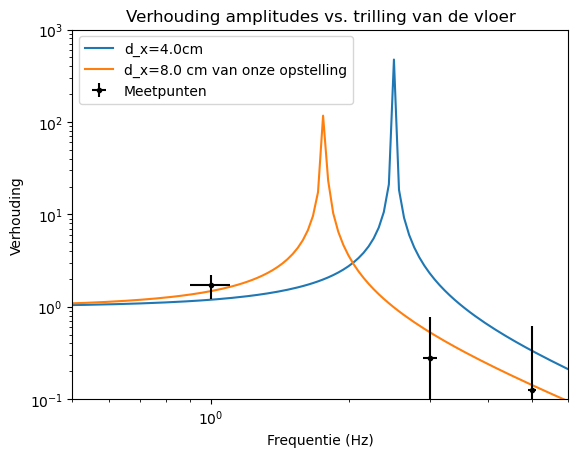

In [8]:
# Voeg hier je plot in.
kantelfrequentie = 2.5
f = np.logspace(-1, 10, 1000)

def verhouding(f):
    return np.abs(1 / (1-((f)**2/(kantelfrequentie)**2)))

y = verhouding(f)

kantelfrequentie2= np.sqrt(9.81/0.08)/(2*np.pi)

def verhouding2(f):
    return np.abs(1 / (1-((f)**2/(kantelfrequentie2)**2)))

y2= verhouding2(f)
Frequentie_metingen = np.array([1,3,5])
Am = np.array([1.7,0.7,0.5])
Av = np.array([1,2.5,4])
Verhouding_metingen = Am/Av
    
 
# Voeg hier je plot in.
plt.figure()
plt.loglog(f, y, label='d_x=4.0cm')
plt.loglog(f, y2, label='d_x=8.0 cm van onze opstelling')
plt.errorbar(Frequentie_metingen,Verhouding_metingen, yerr=0.5, xerr=0.1, fmt='k.',label='Meetpunten')
plt.xlim(left=0.5,right = 6)
plt.ylim(bottom=0.1, top=1e3)
plt.xlabel('Frequentie (Hz)')
plt.ylabel('Verhouding')
plt.title('Verhouding amplitudes vs. trilling van de vloer')
plt.legend()
plt.show()

## Opdracht 8: Leerdoelen
Voeg hieronder zelf kopjes toe om aan te geven wat bij welk leerdoel hoort. 

Inzien dat de parameters in een differentiaalvergelijking ontwerpparameters zijn die een ontwerpruimte opspannen :

We hebben een massa-veer systeem geanalyseerd die wordt beschreven door een differentiaal vergelijking (uitleg in hoorcollege). Hierin hebben de rol van meerdere parameters zoals de massa, veerkonstante en uitrekking delta_x bestudeerd. Een varierende delta_x veroorzaakt een verranderende kantalfrequentie, en hierdoor amplitude verhouding. De grafiek laat zien dat trillingen beter gedempt worden bij een hogere delta_x. Het gedrag van het systeem wordt dus bepaalt door de parameters en spannen dus een bepaalde ontwerpruimte op. 

<img src="schets.png" width="400">

Op basis van een differentiaal vergelijking een keuze maken voor parameters en die vervolgens kunnen vertalen in een fysiek ontwerp:

Op basis van onze analyse en de eisen van de opdracht hebben wij delta_x=8 cm gekozen, en een opstelling ontworpen met een geschikte massa, veer (dus geschikte veerconstante) en materiaal voor het correct meten. We merken dat ons eigen theoretisch model (oranje)voldoet aan de trillingsreductie-eis aangezien de verhouding veel kleiner is dan de drempel grafiek (blauw). Vervolgens is te zien dat de verhouding van de amplitude van onze massa over de amplitude van de vloer die wij gemeten hebben overeenkomt (zwarte meetpunten) met het theoretisch model gebaseerd op onze opstelling (dankzij onze  gekozen delta_x) (blauw), en dat ons ontwerp dus correct is uitgevoerd.

<img src="figuur13.png" width="400">